# Predict — classify an aircraft photo

Loads the trained model from `models/` and identifies the aircraft. Includes a
**random spot-check**: pull a random image from your 5 classes, show its TRUE
label, and compare with the model's prediction.

> Prerequisite: run the **save** cell in notebook 03 so
> `models/resnet18_aircraft5.pt` exists.

## 1. Load the saved model

In [1]:
import sys
sys.path.append('..')
import torch
from src.predict import load_model, predict

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model, classes = load_model('../models/resnet18_aircraft5.pt', device=device)
print('Model loaded on', device, '| classes:', classes)

Model loaded on cuda | classes: ['Boeing 737', 'A320', 'A340', 'Boeing 777', 'A380']


## 2. Get the test set (only your 5 classes, with known true labels)

In [2]:
from src.data import get_dataloaders

# We reuse the data pipeline. The loader's .dataset is the filtered test set,
# which only contains your 5 classes AND knows each image's true label.
_, _, test_loader, classes = get_dataloaders('../data')
test_ds = test_loader.dataset
print('Test images across your 5 classes:', len(test_ds))

Test images across your 5 classes: 635


## 3. Random spot-check

**Re-run this cell** to draw a new random aircraft. It shows the true label and
the model's prediction so you can see if it's right.

In [18]:
import random

# Pick a random sample from the 5-class test set, and get its path + TRUE label.
i = random.randrange(len(test_ds))
img_path, true_name = test_ds.path_and_label(i)

# Ask the model.
ranked = predict(model, classes, img_path, device=device)
pred_name, pred_conf = ranked[0]

print('True aircraft :', true_name)
print(f'Predicted     : {pred_name}  ({pred_conf * 100:.1f}%)')
print('Result        :', 'CORRECT' if pred_name == true_name else 'WRONG')
print('\nAll confidences:')
for name, prob in ranked:
    print(f'  {name:11s} {prob * 100:5.1f}%')

True aircraft : A380
Predicted     : Boeing 777  (97.8%)
Result        : WRONG

All confidences:
  Boeing 777   97.8%
  A340          1.7%
  A320          0.4%
  A380          0.1%
  Boeing 737    0.0%


## Grad-CAM overlay (heatmap + green box)

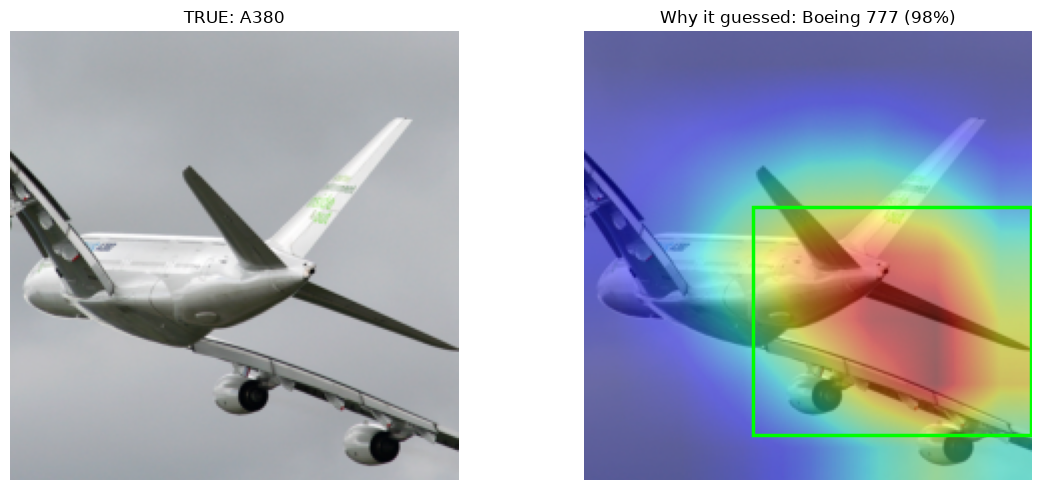

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image
from src.explain import grad_cam

# Explain the PREDICTED class (top of `ranked` from the spot-check cell).
pred_idx = classes.index(ranked[0][0])
cam, used_idx = grad_cam(model, img_path, class_idx=pred_idx, device=device)

# Show the image exactly as the model sees it (Resize 256 -> CenterCrop 224) so
# the 224x224 heatmap lines up correctly.
disp_tf = transforms.Compose([transforms.Resize(256), transforms.CenterCrop(224)])
img_np = np.array(disp_tf(Image.open(img_path).convert('RGB')))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.imshow(img_np); ax1.axis('off'); ax1.set_title(f'TRUE: {true_name}')

ax2.imshow(img_np)
ax2.imshow(cam, cmap='jet', alpha=0.45)          # red = most important regions
# Green box around the hottest region (the overlay you asked for).
ys, xs = np.where(cam > 0.6)
if len(xs):
    rect = plt.Rectangle((xs.min(), ys.min()), xs.max() - xs.min(), ys.max() - ys.min(),
                         edgecolor='lime', facecolor='none', lw=2.5)
    ax2.add_patch(rect)
ax2.axis('off')
ax2.set_title(f'Why it guessed: {classes[used_idx]} ({ranked[0][1] * 100:.0f}%)')
plt.tight_layout(); plt.show()

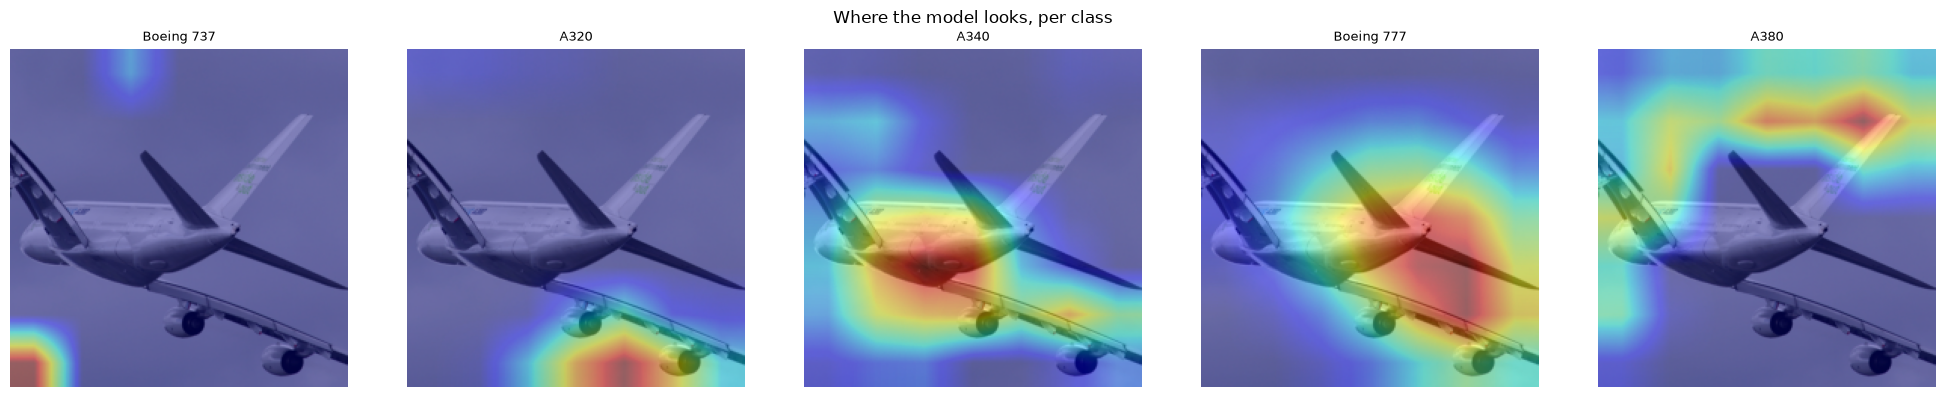

In [20]:
fig, axes = plt.subplots(1, len(classes), figsize=(4 * len(classes), 4))
for ax, cls in zip(axes, classes):
    cam_c, _ = grad_cam(model, img_path, class_idx=classes.index(cls), device=device)
    ax.imshow(img_np); ax.imshow(cam_c, cmap='jet', alpha=0.45)
    ax.axis('off'); ax.set_title(cls, fontsize=9)
plt.suptitle('Where the model looks, per class'); plt.tight_layout(); plt.show()

## 4. Visualise (image + true vs predicted)

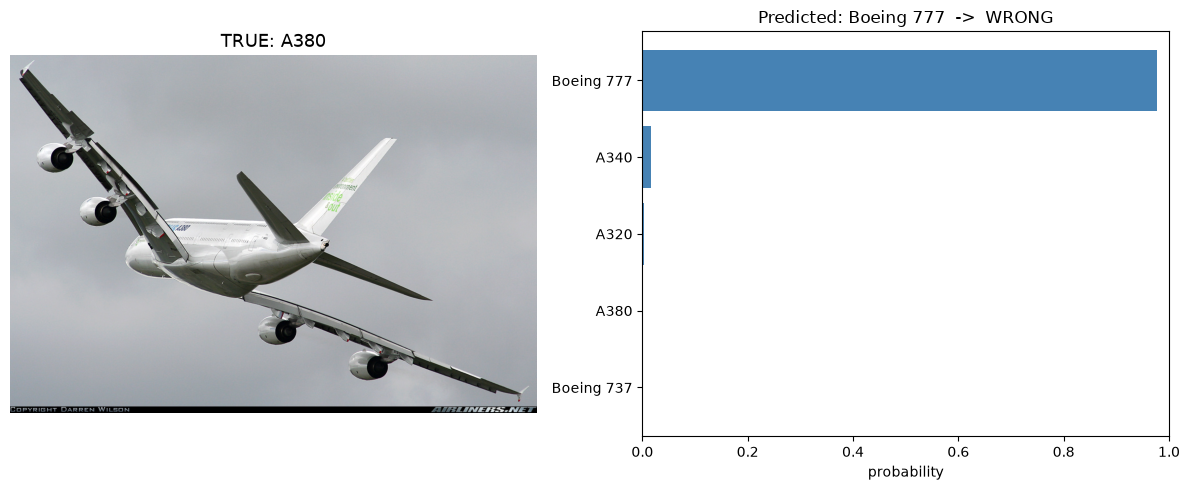

In [21]:
import matplotlib.pyplot as plt
from PIL import Image

img = Image.open(img_path).convert('RGB')
names = [c for c, _ in ranked][::-1]
probs = [p for _, p in ranked][::-1]
correct = pred_name == true_name

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.imshow(img)
ax1.axis('off')
# True label shown UNDER the image so you can cross-check.
ax1.set_title(f'TRUE: {true_name}', fontsize=13)
ax2.barh(names, probs, color=['green' if n == true_name else 'steelblue' for n in names])
ax2.set_xlim(0, 1)
ax2.set_xlabel('probability')
ax2.set_title(f"Predicted: {pred_name}  ->  {'CORRECT' if correct else 'WRONG'}")
plt.tight_layout()
plt.show()

## 5. (Optional) predict on YOUR own photo

For an image from outside the dataset (no known label), just predict directly.

In [22]:
# MY_PHOTO = '../data/my_plane.jpg'   # <- set to your image path, then uncomment
# for name, prob in predict(model, classes, MY_PHOTO, device=device):
#     print(f'  {name:11s} {prob * 100:5.1f}%')